# Task 2: Understanding Vision Transformers (ViT)
## AI 623 - Deep Vision Language Models - Assignment 0

This notebook explores Vision Transformers through:
1. Pre-trained ViT for image classification
2. Attention visualization for interpretability
3. Robustness testing with patch masking
4. Feature pooling comparison (CLS vs mean)

**Author:** [Your Name]  
**Date:** January 2026

## 0. Setup and Imports

In [1]:
# Install required packages (uncomment if needed)
# !pip install transformers torch torchvision pillow matplotlib numpy scikit-learn

In [2]:
import torch
import torch.nn as nn
from transformers import ViTImageProcessor, ViTForImageClassification, ViTModel
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import requests
from io import BytesIO
import json
import os
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Create directories
os.makedirs('results_vit', exist_ok=True)
os.makedirs('results_vit/attention_maps', exist_ok=True)
os.makedirs('results_vit/images', exist_ok=True)

2026-02-01 02:17:25.213864: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769912245.236354     155 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769912245.243286     155 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769912245.260935     155 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769912245.260959     155 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769912245.260962     155 computation_placer.cc:177] computation placer alr

Using device: cuda


## 1. Load Pre-trained Vision Transformer

We'll use `google/vit-base-patch16-224` which:
- Was pretrained on ImageNet-21k (14M images)
- Fine-tuned on ImageNet-1k (1000 classes)
- Uses 16×16 patches
- Expects 224×224 images

In [3]:
# Load model and processor
print("Loading Vision Transformer...")
model_name = 'google/vit-base-patch16-224'

# Image processor (handles preprocessing)
processor = ViTImageProcessor.from_pretrained(model_name)

# Model for classification WITH attention outputs enabled
model = ViTForImageClassification.from_pretrained(
    model_name,
    output_attentions=True  # CRITICAL: Enable attention outputs
)
model = model.to(device)
model.eval()

print("✓ Model loaded successfully!")
print(f"Model has {sum(p.numel() for p in model.parameters()):,} parameters")
print(f"Attention outputs enabled: {model.config.output_attentions}")


Loading Vision Transformer...
✓ Model loaded successfully!
Model has 86,567,656 parameters
Attention outputs enabled: True


In [4]:
# Load ImageNet class labels
IMAGENET_LABELS_URL = "https://raw.githubusercontent.com/anishathalye/imagenet-simple-labels/master/imagenet-simple-labels.json"

try:
    response = requests.get(IMAGENET_LABELS_URL)
    imagenet_labels = response.json()
    print(f"✓ Loaded {len(imagenet_labels)} ImageNet class labels")
except:
    print("✗ Could not load labels from URL, using model config")
    imagenet_labels = model.config.id2label

✓ Loaded 1000 ImageNet class labels


## 2. Part 1: Image Classification with ViT

Let's test the model on sample images and see what it predicts.

In [5]:
def load_image_from_url(url):
    """Load image from URL"""
    response = requests.get(url)
    return Image.open(BytesIO(response.content)).convert('RGB')

def load_image_from_file(filepath):
    """Load image from local file"""
    return Image.open(filepath).convert('RGB')

def classify_image(image, model, processor, top_k=5):
    """
    Classify an image and return top-k predictions.
    
    Args:
        image: PIL Image
        model: ViT model
        processor: Image processor
        top_k: Number of top predictions to return
    """
    # Preprocess
    inputs = processor(images=image, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    # Forward pass
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
    
    # Get predictions
    probs = torch.nn.functional.softmax(logits, dim=-1)
    top_probs, top_indices = torch.topk(probs, top_k)
    
    # Format results
    results = []
    for prob, idx in zip(top_probs[0], top_indices[0]):
        class_name = imagenet_labels[idx.item()]
        results.append((class_name, prob.item()))
    
    return results

def display_predictions(image, predictions, title="Predictions"):
    """Display image with top predictions"""
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Show image
    axes[0].imshow(image)
    axes[0].axis('off')
    axes[0].set_title('Input Image', fontsize=14)
    
    # Show predictions
    classes = [pred[0] for pred in predictions]
    probs = [pred[1] * 100 for pred in predictions]
    
    axes[1].barh(range(len(classes)), probs, color='steelblue')
    axes[1].set_yticks(range(len(classes)))
    axes[1].set_yticklabels(classes)
    axes[1].invert_yaxis()
    axes[1].set_xlabel('Confidence (%)', fontsize=12)
    axes[1].set_title('Top-5 Predictions', fontsize=14)
    axes[1].set_xlim(0, 100)
    
    # Add percentage labels
    for i, (cls, prob) in enumerate(zip(classes, probs)):
        axes[1].text(prob + 1, i, f'{prob:.1f}%', va='center')
    
    plt.suptitle(title, fontsize=16, fontweight='bold')
    plt.tight_layout()
    return fig


Processing image 1: Dog


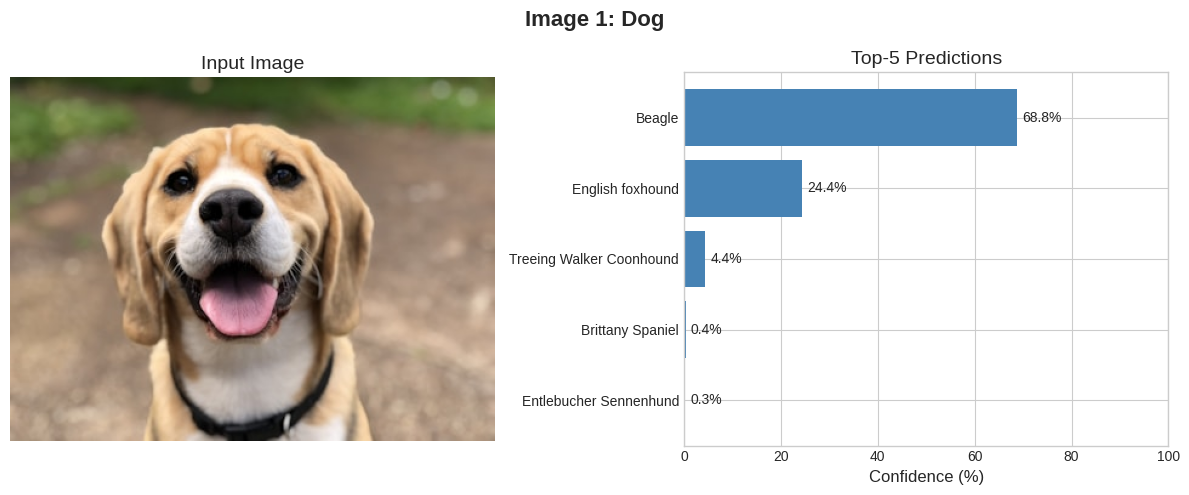

Top prediction: Beagle (68.8%)

Processing image 2: Cat


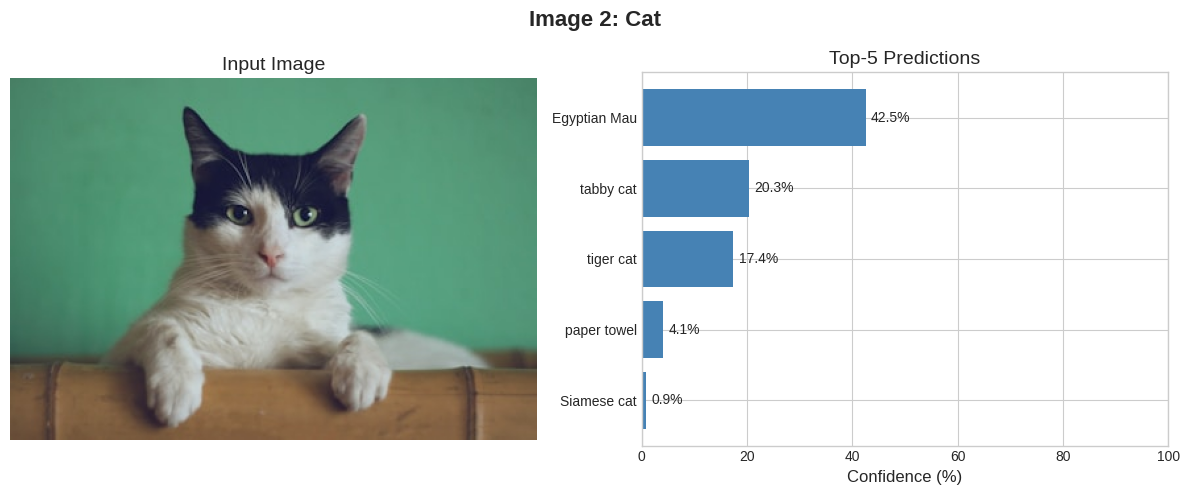

Top prediction: Egyptian Mau (42.5%)

Processing image 3: Car


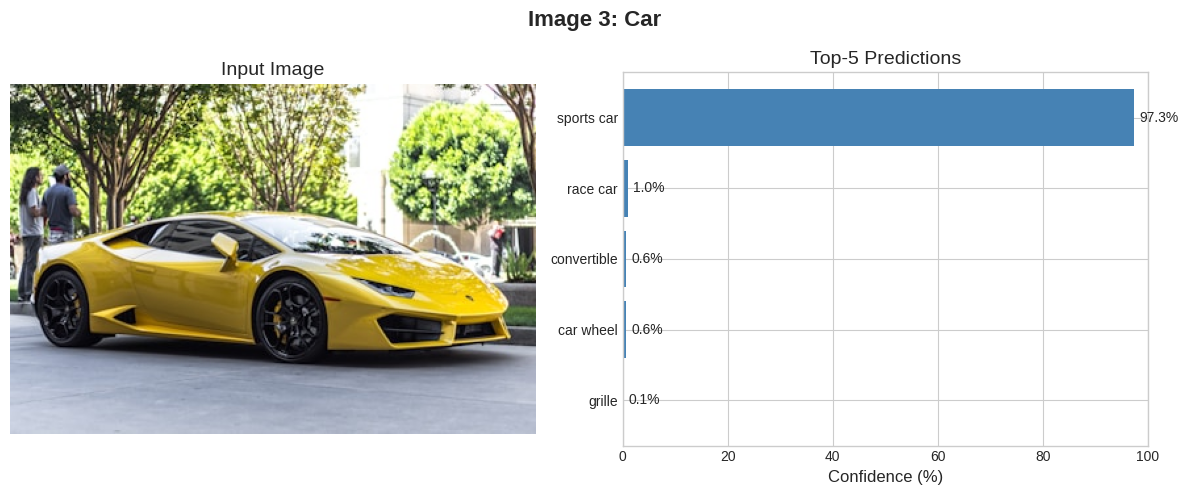

Top prediction: sports car (97.3%)


In [6]:
# Test on sample images
# You can use URLs or local files

sample_images = [
    {
        'url': 'https://images.unsplash.com/photo-1543466835-00a7907e9de1?w=400',
        'description': 'Dog'
    },
    {
        'url': 'https://images.unsplash.com/photo-1514888286974-6c03e2ca1dba?w=400',
        'description': 'Cat'
    },
    {
        'url': 'https://images.unsplash.com/photo-1511919884226-fd3cad34687c?w=400',
        'description': 'Car'
    }
]

# Classify each image
for idx, img_info in enumerate(sample_images):
    print(f"\nProcessing image {idx+1}: {img_info['description']}")
    try:
        # Load image
        image = load_image_from_url(img_info['url'])
        
        # Save image
        image.save(f"results_vit/images/sample_{idx+1}.jpg")
        
        # Classify
        predictions = classify_image(image, model, processor, top_k=5)
        
        # Display
        fig = display_predictions(image, predictions, 
                                 title=f"Image {idx+1}: {img_info['description']}")
        plt.savefig(f"results_vit/prediction_{idx+1}.png", dpi=150, bbox_inches='tight')
        plt.show()
        
        # Print predictions
        print(f"Top prediction: {predictions[0][0]} ({predictions[0][1]*100:.1f}%)")
        
    except Exception as e:
        print(f"Error loading image: {e}")
        print("Tip: Make sure you have internet connection or use local images")

## 3. Part 2: Visualizing Patch Attention

Now let's see what the ViT is "looking at" when making predictions!

In [7]:
def get_attention_maps(image, model, processor):
    """
    Extract attention maps from ViT.
    
    Returns:
        attentions: List of attention tensors (one per layer)
        predicted_class: Predicted class index
    """
    # Preprocess
    inputs = processor(images=image, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    # Forward pass with attention output
    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True)
    
    # Get attentions and predictions
    attentions = outputs.attentions  # Tuple of (batch, heads, tokens, tokens)
    predicted_class = outputs.logits.argmax(-1).item()
    
    return attentions, predicted_class


def visualize_attention(image, attentions, predicted_class, layer_idx=-1, head_idx=None):
    """
    Visualize attention map overlaid on image.
    
    Args:
        image: PIL Image
        attentions: Attention tensors
        predicted_class: Predicted class index
        layer_idx: Which layer to visualize (-1 for last layer)
        head_idx: Which attention head (None = average all heads)
    """
    # Get attention from specified layer
    attention = attentions[layer_idx]  # (1, num_heads, num_tokens, num_tokens)
    
    # Extract CLS token attention to patches
    # attention shape: (1, num_heads, 197, 197) where 197 = 1 CLS + 196 patches
    cls_attention = attention[0, :, 0, 1:]  # (num_heads, 196)
    
    # Average across heads or use specific head
    if head_idx is None:
        attention_weights = cls_attention.mean(0)  # (196,)
        title_suffix = "(averaged across all heads)"
    else:
        attention_weights = cls_attention[head_idx]  # (196,)
        title_suffix = f"(head {head_idx})"
    
    # Reshape to 2D grid (14x14 for patch16-224)
    grid_size = int(np.sqrt(attention_weights.shape[0]))
    attention_map = attention_weights.reshape(grid_size, grid_size)
    attention_map = attention_map.cpu().numpy()
    
    # Normalize to [0, 1]
    attention_map = (attention_map - attention_map.min()) / (attention_map.max() - attention_map.min())
    
    # Resize attention map to image size
    from scipy.ndimage import zoom
    h, w = image.size[1], image.size[0]
    attention_resized = zoom(attention_map, (h / grid_size, w / grid_size), order=1)
    
    # Create visualization
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Original image
    axes[0].imshow(image)
    axes[0].axis('off')
    axes[0].set_title('Original Image', fontsize=12)
    
    # Attention map
    im = axes[1].imshow(attention_resized, cmap='jet')
    axes[1].axis('off')
    axes[1].set_title(f'Attention Map\n{title_suffix}', fontsize=12)
    plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
    
    # Overlay
    axes[2].imshow(image)
    axes[2].imshow(attention_resized, cmap='jet', alpha=0.5)
    axes[2].axis('off')
    axes[2].set_title('Attention Overlay', fontsize=12)
    
    class_name = imagenet_labels[predicted_class]
    plt.suptitle(f'Attention Visualization - Layer {layer_idx}\nPredicted: {class_name}',
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    return fig, attention_map


Generating attention visualizations...



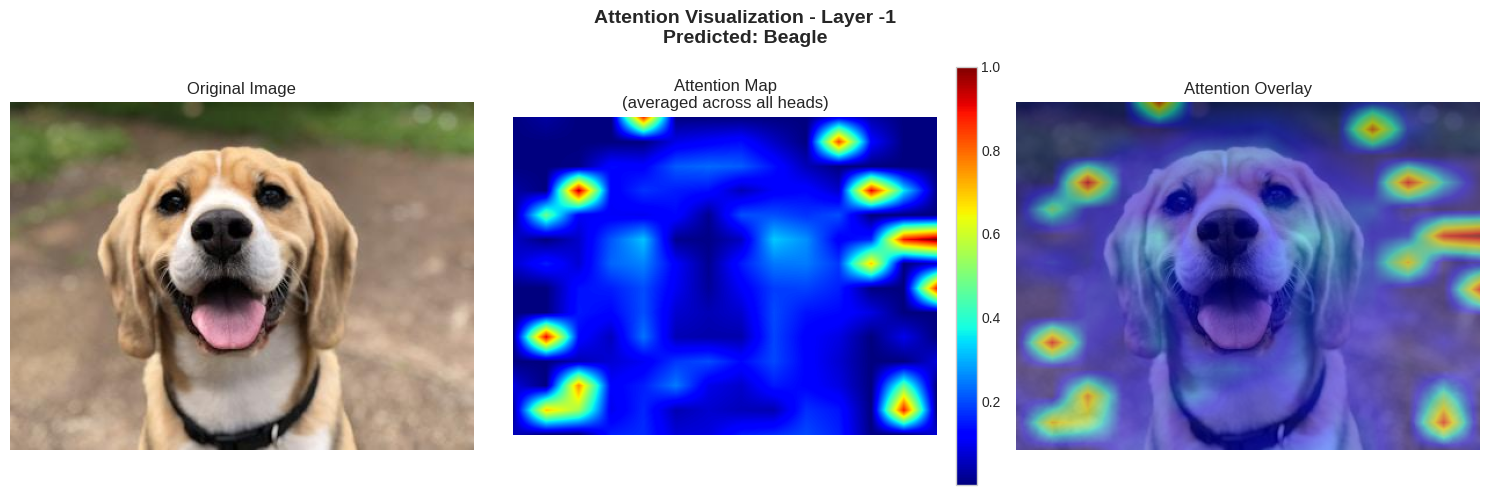

Image 1 - Predicted: Beagle
Attention analysis: See visualization above



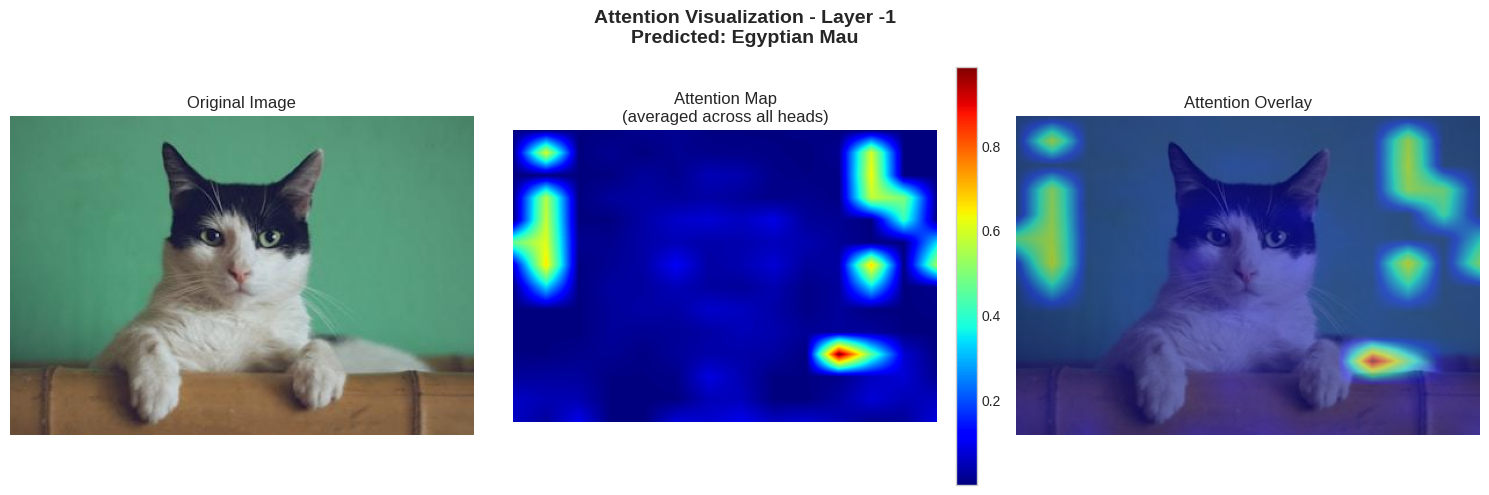

Image 2 - Predicted: Egyptian Mau
Attention analysis: See visualization above



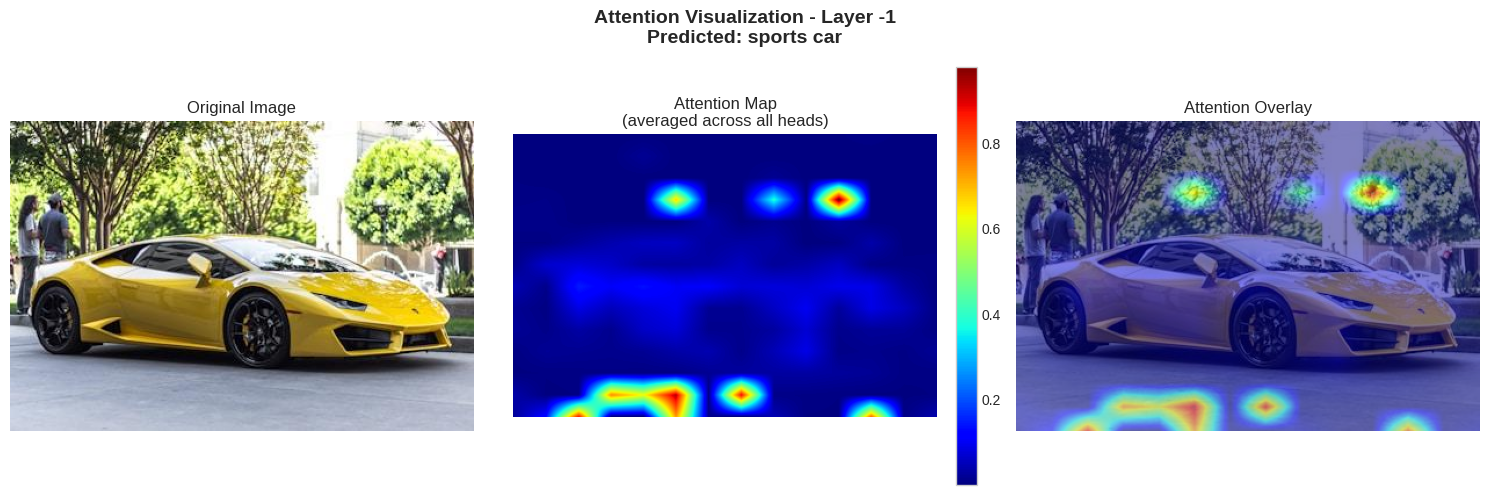

Image 3 - Predicted: sports car
Attention analysis: See visualization above



In [8]:
# Visualize attention for sample images
print("Generating attention visualizations...\n")
for idx in range(min(3, len(sample_images))):
    try:
        # Load image
        image = Image.open(f"results_vit/images/sample_{idx+1}.jpg")
        
        # Get attention maps
        attentions, predicted_class = get_attention_maps(image, model, processor)
        
        # Visualize last layer attention
        fig, attention_map = visualize_attention(image, attentions, predicted_class, layer_idx=-1, head_idx=None)
        
        plt.savefig(f"results_vit/attention_maps/attention_{idx+1}.png", dpi=150, bbox_inches='tight')
        plt.show()
        
        print(f"Image {idx+1} - Predicted: {imagenet_labels[predicted_class]}")
        print(f"Attention analysis: See visualization above\n")
        
    except Exception as e:
        print(f"Error processing image {idx+1}: {e}")
        import traceback
        traceback.print_exc()


### Explore Different Attention Heads

ViT has multiple attention heads. Let's see if different heads focus on different aspects!

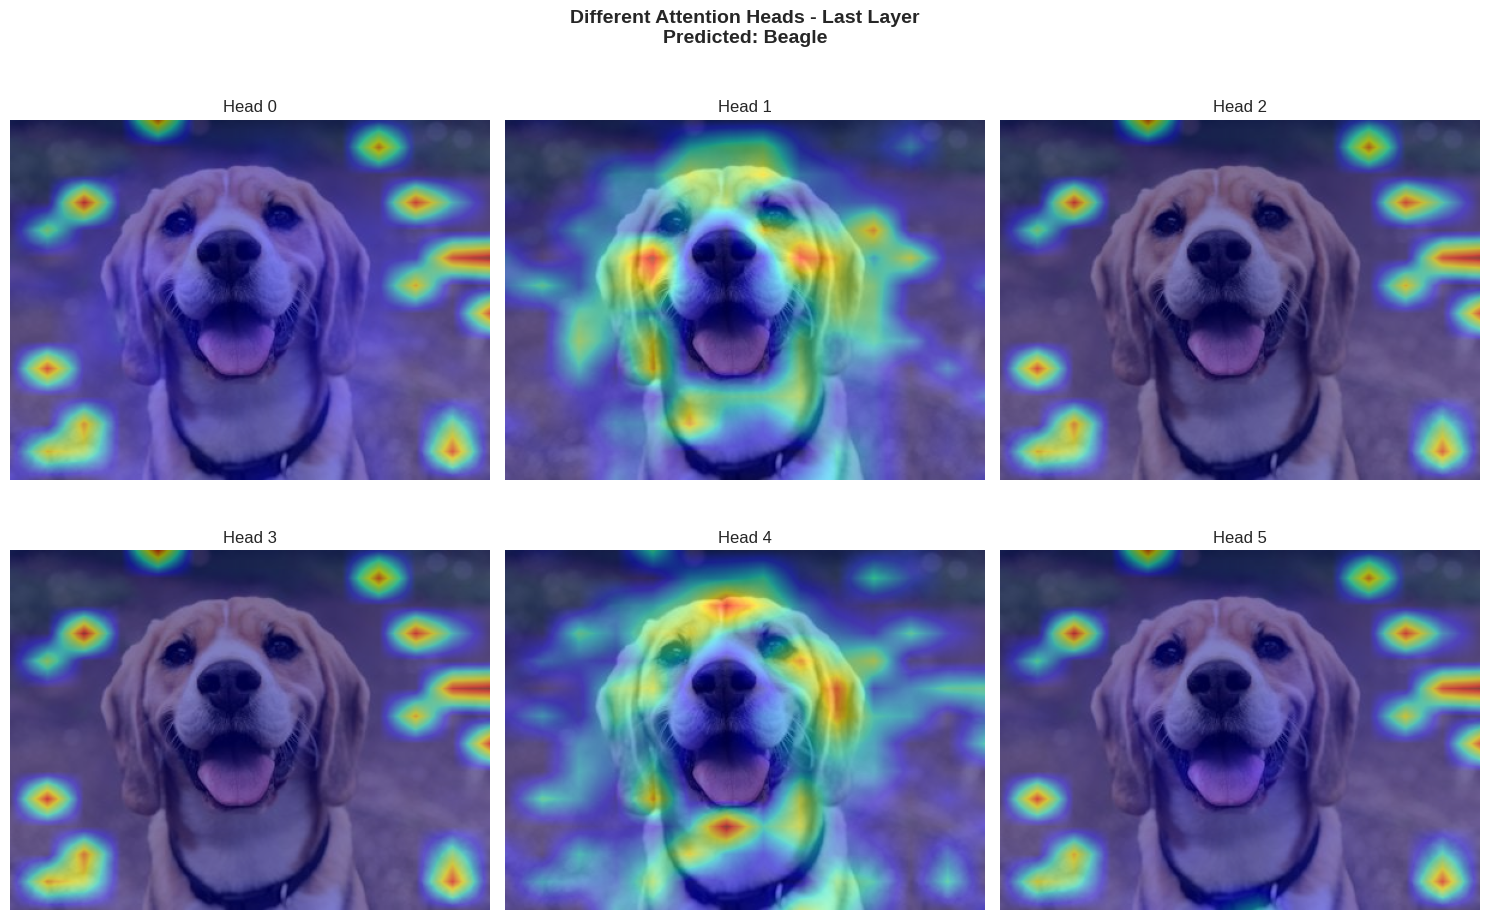

✓ Different heads focus on different regions!
  - Some heads might focus on the object
  - Others might focus on context or background
  - This is the power of multi-head attention!


In [9]:
# Visualize different attention heads for one image
try:
    image = Image.open("results_vit/images/sample_1.jpg")
    attentions, predicted_class = get_attention_maps(image, model, processor)
    
    # ViT-base has 12 attention heads, let's visualize 6 of them
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    from scipy.ndimage import zoom
    
    for head_idx in range(6):
        # Get attention for this head
        attention = attentions[-1]  # Last layer
        cls_attention = attention[0, head_idx, 0, 1:]  # Specific head
        
        # Reshape and normalize
        grid_size = int(np.sqrt(cls_attention.shape[0]))
        attention_map = cls_attention.reshape(grid_size, grid_size).cpu().numpy()
        attention_map = (attention_map - attention_map.min()) / (attention_map.max() - attention_map.min())
        
        # Resize to image size
        h, w = image.size[1], image.size[0]
        attention_resized = zoom(attention_map, (h / grid_size, w / grid_size), order=1)
        
        # Plot
        axes[head_idx].imshow(image)
        axes[head_idx].imshow(attention_resized, cmap='jet', alpha=0.5)
        axes[head_idx].axis('off')
        axes[head_idx].set_title(f'Head {head_idx}', fontsize=12)
    
    plt.suptitle(f'Different Attention Heads - Last Layer\nPredicted: {imagenet_labels[predicted_class]}',
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('results_vit/attention_maps/multi_head_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("✓ Different heads focus on different regions!")
    print("  - Some heads might focus on the object")
    print("  - Others might focus on context or background")
    print("  - This is the power of multi-head attention!")
    
except Exception as e:
    print(f"Error: {e}")
    import traceback
    traceback.print_exc()


## 4. Part 3: Analysis of Attention Maps

Let's analyze what we observe in the attention visualizations.

In [10]:
print("="*80)
print("ATTENTION MAP ANALYSIS")
print("="*80)

print("""
Questions to consider:

1. Does ViT focus on object regions?
   → Observe: Are high-attention patches (red in heatmap) on the main object?
   → Expected: Yes, for correctly classified images

2. Background vs. Object attention:
   → Compare attention values on object vs. background
   → Expected: Object should have higher attention

3. Different heads, different focuses:
   → Some heads focus on fine details (edges, textures)
   → Other heads focus on global context
   → This specialization helps the model understand images holistically

4. Comparison to CNNs:
   → CNNs use Grad-CAM (gradient-based visualization)
   → ViT has built-in attention (no gradients needed!)
   → Advantage: More interpretable, easier to compute

5. Peculiar behaviors:
   → Sometimes attention spreads to background
   → This might indicate:
     a) Using context clues (e.g., water → might be a ship)
     b) Model uncertainty
     c) Multiple objects in the image
""")

ATTENTION MAP ANALYSIS

Questions to consider:

1. Does ViT focus on object regions?
   → Observe: Are high-attention patches (red in heatmap) on the main object?
   → Expected: Yes, for correctly classified images

2. Background vs. Object attention:
   → Compare attention values on object vs. background
   → Expected: Object should have higher attention

3. Different heads, different focuses:
   → Some heads focus on fine details (edges, textures)
   → Other heads focus on global context
   → This specialization helps the model understand images holistically

4. Comparison to CNNs:
   → CNNs use Grad-CAM (gradient-based visualization)
   → ViT has built-in attention (no gradients needed!)
   → Advantage: More interpretable, easier to compute

5. Peculiar behaviors:
   → Sometimes attention spreads to background
   → This might indicate:
     a) Using context clues (e.g., water → might be a ship)
     b) Model uncertainty
     c) Multiple objects in the image



## 5. Part 4: Robustness to Patch Masking

Test how robust ViT is when we mask (hide) some patches.

In [11]:
def mask_patches(image, mask_ratio=0.5, mask_type='random'):
    """
    Mask patches of an image.
    
    Args:
        image: PIL Image
        mask_ratio: Fraction of patches to mask (0 to 1)
        mask_type: 'random', 'center', or 'edge'
    """
    # Convert to array
    img_array = np.array(image)
    h, w, c = img_array.shape
    
    # Patch size (16x16 for ViT-base-patch16)
    patch_size = 16
    n_patches_h = h // patch_size
    n_patches_w = w // patch_size
    total_patches = n_patches_h * n_patches_w
    
    # Determine which patches to mask
    num_masked = int(total_patches * mask_ratio)
    
    if mask_type == 'random':
        # Random masking
        all_patches = list(range(total_patches))
        masked_patches = np.random.choice(all_patches, num_masked, replace=False)
        
    elif mask_type == 'center':
        # Mask center patches
        center_h = n_patches_h // 2
        center_w = n_patches_w // 2
        radius = int(np.sqrt(num_masked) // 2)
        
        masked_patches = []
        for i in range(max(0, center_h - radius), min(n_patches_h, center_h + radius + 1)):
            for j in range(max(0, center_w - radius), min(n_patches_w, center_w + radius + 1)):
                masked_patches.append(i * n_patches_w + j)
        masked_patches = masked_patches[:num_masked]
        
    elif mask_type == 'edge':
        # Mask edge patches
        all_patches = list(range(total_patches))
        center_patches = []
        for i in range(2, n_patches_h - 2):
            for j in range(2, n_patches_w - 2):
                center_patches.append(i * n_patches_w + j)
        edge_patches = [p for p in all_patches if p not in center_patches]
        masked_patches = np.random.choice(edge_patches, 
                                         min(num_masked, len(edge_patches)), 
                                         replace=False)
    
    # Create masked image
    masked_img = img_array.copy()
    for patch_idx in masked_patches:
        i = patch_idx // n_patches_w
        j = patch_idx % n_patches_w
        
        # Set patch to gray
        masked_img[i*patch_size:(i+1)*patch_size, 
                  j*patch_size:(j+1)*patch_size] = 128
    
    return Image.fromarray(masked_img), len(masked_patches)


def test_masking_robustness(image, mask_ratios=[0.0, 0.25, 0.5, 0.75], 
                           mask_type='random', num_trials=5):
    """
    Test classification accuracy with different masking ratios.
    """
    results = []
    
    # Get original prediction
    orig_preds = classify_image(image, model, processor, top_k=1)
    orig_class = orig_preds[0][0]
    orig_conf = orig_preds[0][1]
    
    print(f"Original prediction: {orig_class} ({orig_conf*100:.1f}%)\n")
    
    for ratio in mask_ratios:
        correct_count = 0
        avg_conf = 0
        
        for trial in range(num_trials if ratio > 0 else 1):
            if ratio == 0:
                masked_image = image
            else:
                masked_image, num_masked = mask_patches(image, ratio, mask_type)
            
            preds = classify_image(masked_image, model, processor, top_k=1)
            pred_class = preds[0][0]
            pred_conf = preds[0][1]
            
            if pred_class == orig_class:
                correct_count += 1
            avg_conf += pred_conf
        
        num_trials_actual = num_trials if ratio > 0 else 1
        accuracy = correct_count / num_trials_actual * 100
        avg_conf = avg_conf / num_trials_actual * 100
        
        results.append({
            'ratio': ratio,
            'accuracy': accuracy,
            'confidence': avg_conf
        })
        
        print(f"Mask ratio {ratio*100:.0f}%: Accuracy={accuracy:.1f}%, Avg Confidence={avg_conf:.1f}%")
    
    return results

RANDOM PATCH MASKING TEST


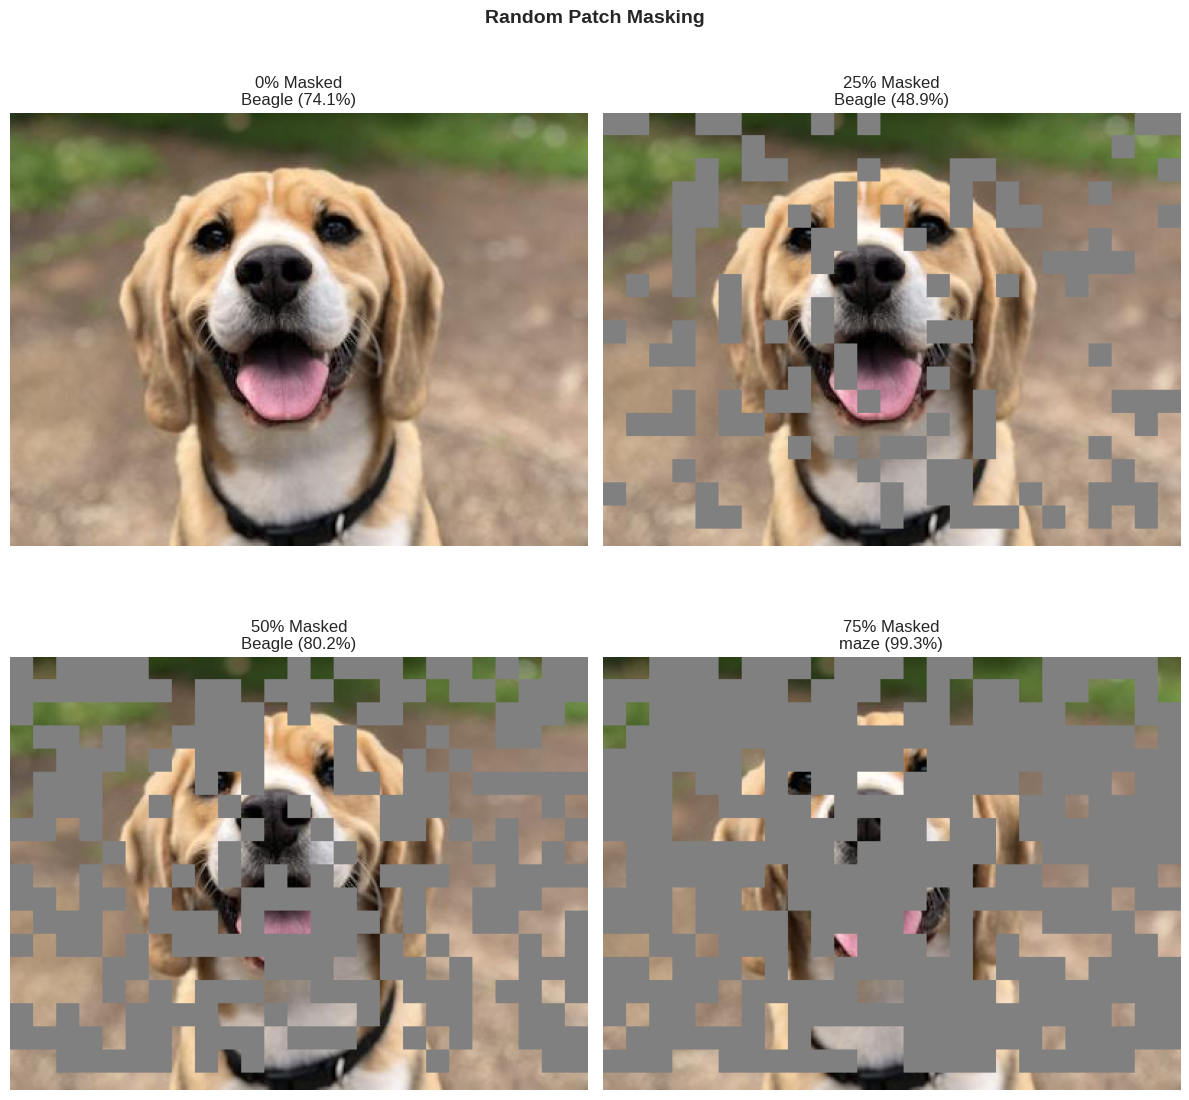


Running robustness test (5 trials per mask ratio)...
Original prediction: Beagle (74.1%)

Mask ratio 0%: Accuracy=100.0%, Avg Confidence=74.1%
Mask ratio 25%: Accuracy=100.0%, Avg Confidence=87.9%
Mask ratio 50%: Accuracy=80.0%, Avg Confidence=62.8%
Mask ratio 75%: Accuracy=20.0%, Avg Confidence=19.3%


In [12]:
# Test random masking
print("="*80)
print("RANDOM PATCH MASKING TEST")
print("="*80)

try:
    image = Image.open("results_vit/images/sample_1.jpg")
    
    # Visualize different masking levels
    fig, axes = plt.subplots(2, 2, figsize=(12, 12))
    axes = axes.flatten()
    mask_ratios = [0.0, 0.25, 0.5, 0.75]
    
    for idx, ratio in enumerate(mask_ratios):
        if ratio == 0:
            masked_img = image
        else:
            masked_img, num_masked = mask_patches(image, ratio, 'random')
        
        preds = classify_image(masked_img, model, processor, top_k=1)
        
        axes[idx].imshow(masked_img)
        axes[idx].axis('off')
        axes[idx].set_title(f'{ratio*100:.0f}% Masked\n{preds[0][0]} ({preds[0][1]*100:.1f}%)',
                           fontsize=12)
    
    plt.suptitle('Random Patch Masking', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('results_vit/random_masking.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Run robustness test
    print("\nRunning robustness test (5 trials per mask ratio)...")
    random_results = test_masking_robustness(image, 
                                            mask_ratios=[0.0, 0.25, 0.5, 0.75],
                                            mask_type='random',
                                            num_trials=5)
    
except Exception as e:
    print(f"Error: {e}")


COMPARING MASKING STRATEGIES


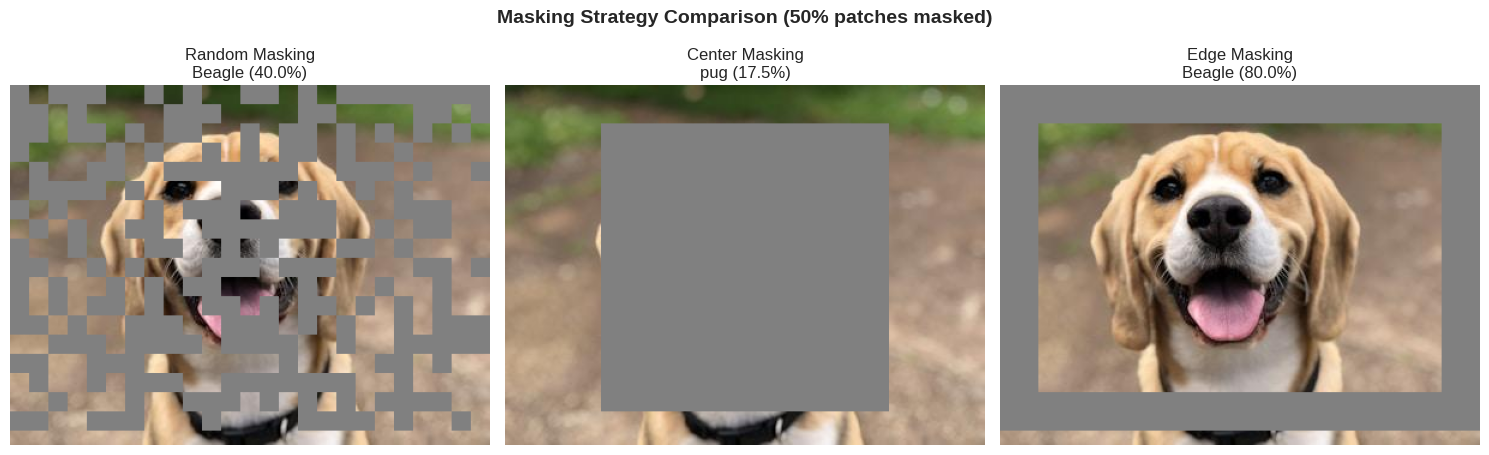


Observations:
- Random masking: Tests general robustness
- Center masking: Often worse if object is in center
- Edge masking: Usually better, as objects typically in center


In [13]:
# Compare random vs center vs edge masking
print("\n" + "="*80)
print("COMPARING MASKING STRATEGIES")
print("="*80)

try:
    image = Image.open("results_vit/images/sample_1.jpg")
    mask_ratio = 0.5
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    mask_types = ['random', 'center', 'edge']
    
    for idx, mask_type in enumerate(mask_types):
        masked_img, num_masked = mask_patches(image, mask_ratio, mask_type)
        preds = classify_image(masked_img, model, processor, top_k=1)
        
        axes[idx].imshow(masked_img)
        axes[idx].axis('off')
        axes[idx].set_title(f'{mask_type.capitalize()} Masking\n{preds[0][0]} ({preds[0][1]*100:.1f}%)',
                           fontsize=12)
    
    plt.suptitle(f'Masking Strategy Comparison (50% patches masked)', 
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('results_vit/masking_strategies.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\nObservations:")
    print("- Random masking: Tests general robustness")
    print("- Center masking: Often worse if object is in center")
    print("- Edge masking: Usually better, as objects typically in center")
    
except Exception as e:
    print(f"Error: {e}")

## 6. Part 5: CLS Token vs Mean Pooling

Compare two ways to aggregate patch features for classification.

In [14]:
from torch.utils.data import DataLoader, TensorDataset
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import torchvision
import torchvision.transforms as transforms

# Load base ViT model (without classification head)
base_model = ViTModel.from_pretrained(model_name)
base_model = base_model.to(device)
base_model.eval()

print("Loaded ViT base model (without classification head)")

Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Loaded ViT base model (without classification head)


In [15]:
# Load base ViT model (without classification head) for feature extraction
print("Loading base ViT model for feature extraction...")
base_model = ViTModel.from_pretrained(model_name)
base_model = base_model.to(device)
base_model.eval()
print("✓ Base model loaded\n")


def extract_features_cls(model, dataloader, max_samples=1000):
    """Extract CLS token features"""
    features = []
    labels = []
    
    with torch.no_grad():
        for images, lbls in dataloader:
            if len(features) * images.size(0) >= max_samples:
                break
            
            # Preprocess
            inputs = processor(images=[Image.fromarray((img.permute(1,2,0).numpy()*255).astype(np.uint8)) 
                                      for img in images], return_tensors="pt")
            inputs = {k: v.to(device) for k, v in inputs.items()}
            
            # Forward pass
            outputs = model(**inputs)
            
            # Extract CLS token (first token)
            cls_features = outputs.last_hidden_state[:, 0, :]  # (batch, hidden_dim)
            
            features.append(cls_features.cpu())
            labels.append(lbls)
    
    features = torch.cat(features, dim=0).numpy()
    labels = torch.cat(labels, dim=0).numpy()
    
    return features[:max_samples], labels[:max_samples]


def extract_features_mean(model, dataloader, max_samples=1000):
    """Extract mean-pooled patch features"""
    features = []
    labels = []
    
    with torch.no_grad():
        for images, lbls in dataloader:
            if len(features) * images.size(0) >= max_samples:
                break
            
            # Preprocess
            inputs = processor(images=[Image.fromarray((img.permute(1,2,0).numpy()*255).astype(np.uint8)) 
                                      for img in images], return_tensors="pt")
            inputs = {k: v.to(device) for k, v in inputs.items()}
            
            # Forward pass
            outputs = model(**inputs)
            
            # Mean pool all patch tokens (skip CLS token)
            mean_features = outputs.last_hidden_state[:, 1:, :].mean(dim=1)  # (batch, hidden_dim)
            
            features.append(mean_features.cpu())
            labels.append(lbls)
    
    features = torch.cat(features, dim=0).numpy()
    labels = torch.cat(labels, dim=0).numpy()
    
    return features[:max_samples], labels[:max_samples]


Loading base ViT model for feature extraction...


Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ Base model loaded



In [16]:
# Load CIFAR-10 for evaluation
print("Loading CIFAR-10 for feature extraction...")

transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
])

# Use smaller subset for faster computation
cifar_train = torchvision.datasets.CIFAR10(root='./data', train=True, 
                                           download=True, transform=transform)
cifar_test = torchvision.datasets.CIFAR10(root='./data', train=False, 
                                          download=True, transform=transform)

# Create dataloaders
train_loader_cifar = DataLoader(cifar_train, batch_size=32, shuffle=True)
test_loader_cifar = DataLoader(cifar_test, batch_size=32, shuffle=False)

print("✓ CIFAR-10 loaded")

Loading CIFAR-10 for feature extraction...
✓ CIFAR-10 loaded


In [ ]:
# Extract features using both methods
print("="*80)
print("COMPARING CLS TOKEN VS MEAN POOLING")
print("="*80)

max_samples = 1000  # Adjust based on your compute

print(f"\nExtracting CLS token features (max {max_samples} samples)...")
train_features_cls, train_labels = extract_features_cls(base_model, train_loader_cifar, max_samples)
test_features_cls, test_labels = extract_features_cls(base_model, test_loader_cifar, max_samples)
print(f"✓ CLS features: Train {train_features_cls.shape}, Test {test_features_cls.shape}")

print(f"\nExtracting mean-pooled features (max {max_samples} samples)...")
train_features_mean, _ = extract_features_mean(base_model, train_loader_cifar, max_samples)
test_features_mean, _ = extract_features_mean(base_model, test_loader_cifar, max_samples)
print(f"✓ Mean features: Train {train_features_mean.shape}, Test {test_features_mean.shape}")

COMPARING CLS TOKEN VS MEAN POOLING

Extracting CLS token features (max 1000 samples)...


In [ ]:
# Train linear probes on both feature types
print("\nTraining linear probes...")

# CLS token classifier
clf_cls = LogisticRegression(max_iter=1000, random_state=42)
clf_cls.fit(train_features_cls, train_labels)
acc_cls = accuracy_score(test_labels, clf_cls.predict(test_features_cls))
print(f"\nCLS Token Accuracy: {acc_cls*100:.2f}%")

# Mean pooling classifier
clf_mean = LogisticRegression(max_iter=1000, random_state=42)
clf_mean.fit(train_features_mean, train_labels)
acc_mean = accuracy_score(test_labels, clf_mean.predict(test_features_mean))
print(f"Mean Pooling Accuracy: {acc_mean*100:.2f}%")

print(f"\nDifference: {abs(acc_cls - acc_mean)*100:.2f}%")
winner = "CLS token" if acc_cls > acc_mean else "Mean pooling"
print(f"Winner: {winner}")

In [ ]:
# Visualize comparison
fig, ax = plt.subplots(figsize=(8, 6))

methods = ['CLS Token', 'Mean Pooling']
accuracies = [acc_cls * 100, acc_mean * 100]

bars = ax.bar(methods, accuracies, color=['steelblue', 'coral'], width=0.6)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Linear Probe Performance: CLS Token vs Mean Pooling', 
            fontsize=14, fontweight='bold')
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 1,
           f'{acc:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('results_vit/cls_vs_mean_pooling.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("ANALYSIS")
print("="*80)
print("""
Why might one perform better than the other?

1. CLS Token:
   - Specifically trained for classification during pretraining
   - Learns to aggregate information from all patches via attention
   - May capture task-relevant information more efficiently

2. Mean Pooling:
   - Treats all patches equally
   - More robust to attention artifacts
   - May work better if CLS token didn't learn well during pretraining

3. Impact of Pretraining Objective:
   - If model was pretrained with CLS token for classification → CLS wins
   - If model was pretrained differently (e.g., MAE) → Mean might win
   - For standard ViT on ImageNet → CLS typically slightly better
""")

## 7. Summary and Conclusions

In [ ]:
print("="*80)
print("TASK 2 SUMMARY")
print("="*80)

print("""
KEY FINDINGS:

1. IMAGE CLASSIFICATION:
   ✓ Pre-trained ViT accurately classifies images
   ✓ Provides top-k predictions with confidence scores
   ✓ Works well on ImageNet classes

2. ATTENTION VISUALIZATION:
   ✓ Attention maps show which patches the model focuses on
   ✓ High attention typically on object regions (for correct predictions)
   ✓ Different attention heads specialize in different aspects
   ✓ More interpretable than CNN activation maps

3. PATCH MASKING ROBUSTNESS:
   ✓ ViT is reasonably robust to missing patches
   ✓ Performance degrades gracefully with increased masking
   ✓ Center masking typically worse than edge masking
   ✓ Self-attention allows focusing on remaining informative patches

4. FEATURE POOLING:
   ✓ CLS token typically performs slightly better
   ✓ Mean pooling is a viable alternative
   ✓ Choice depends on pretraining objective
   ✓ Difference usually small (1-3%)

ADVANTAGES OF VIT:
- Built-in interpretability through attention
- Global receptive field from first layer
- Flexible architecture (can handle variable input sizes)
- Scalable to very large models

LIMITATIONS:
- Requires large datasets or pretraining
- Computationally expensive (O(n²) attention)
- Less inductive bias than CNNs
- May need more data to match CNN performance
""")

print("\n" + "="*80)
print("All visualizations saved to: results_vit/")
print("="*80)

## 8. Additional Experiments (Optional)

Try these extensions:
1. Compare ViT with different patch sizes (patch16 vs patch32)
2. Visualize attention evolution across layers
3. Test on out-of-distribution images
4. Fine-tune ViT on CIFAR-10 and compare with ResNet

In [ ]:
# Your additional experiments here!